<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/LiDAR_detection_PC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install nuscenes-devkit open3d numpy matplotlib

INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/316.0 kB ? eta -:--:--
   ------------------------------------- - 307.2/316.0 kB 19.8 MB/s eta 0:00:01
   ---------------------------------------- 316.0/316.0 kB 6.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/69.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.2 MB 16.8 MB/s eta 0:00:05
   - -------------------------------------- 2.1/69.2 MB 21.9 MB/s eta 0:00:04
   -- ------------------------------------- 3.9/69.2 MB 27.6 MB/s eta 0:00:03
   --- ------------------------------------ 5.2/69.2 MB 30.1 MB/s eta 0:00:03
   --- ------------------------------------ 6.7/69.2 MB 30.4 MB/s eta 0:00:03
   ---- ----------------------------------- 8.4/69.2 MB 31.4 MB/s eta 0:00:02
   ----- ---------------------------------- 10.2/69.2 MB 32.6 MB/s eta 0

In [ ]:
import os

DATA_ROOT = os.path.join(os.getcwd(), "v1.0-mini")
print(DATA_ROOT)

C:\Users\Darrick\Documents\LiDAR\v1.0-mini


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=DATA_ROOT,
    verbose=True
)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.862 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.


In [ ]:
rainy_scenes = []

for scene in nusc.scene:
    desc = scene["description"].lower()
    if "rain" in desc:
        rainy_scenes.append(scene)

print(f"Rainy scenes found: {len(rainy_scenes)}")
for s in rainy_scenes:
    print("-", s["name"], ":", s["description"])

Rainy scenes found: 1
- scene-1094 : Night, after rain, many peds, PMD, ped with bag, jaywalker, truck, scooter


In [ ]:
scene = rainy_scenes[0]

sample_token = scene["first_sample_token"]
sample = nusc.get("sample", sample_token)

lidar_token = sample["data"]["LIDAR_TOP"]
lidar_sample = nusc.get("sample_data", lidar_token)

lidar_file = f"{DATA_ROOT}/{lidar_sample['filename']}" # Changed 'file_name' to 'filename'
print("LiDAR file:", lidar_file)

LiDAR file: C:\Users\Darrick\Documents\LiDAR\v1.0-mini/samples/LIDAR_TOP/n015-2018-11-21-19-38-26+0800__LIDAR_TOP__1542800847948119.pcd.bin


In [ ]:
from nuscenes.utils.data_classes import LidarPointCloud
import numpy as np

pc = LidarPointCloud.from_file(lidar_file)
points = pc.points.T   # shape: (N, 4)

xyz = points[:, :3]
intensity = points[:, 3]

print("Points shape:", xyz.shape)

Points shape: (34400, 3)


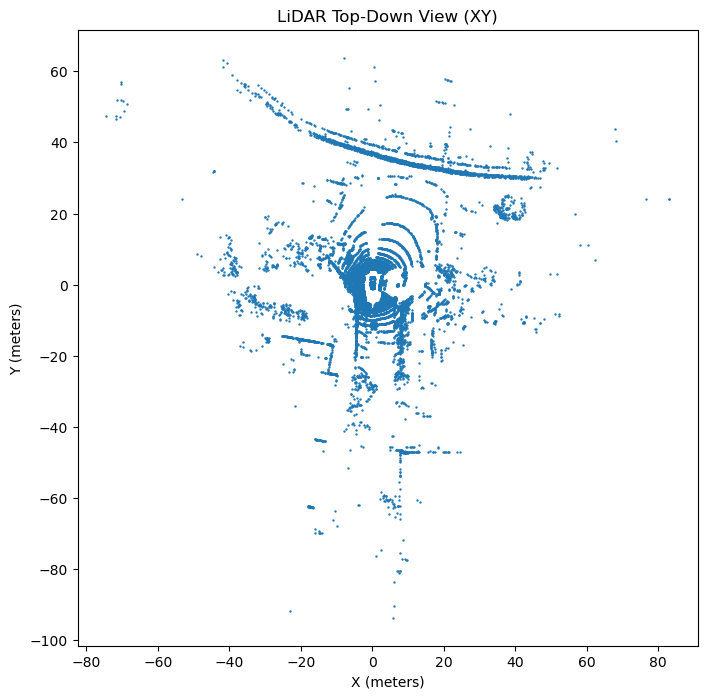

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Downsample for speed
idx = np.random.choice(len(xyz), size=20000, replace=False)
pts = xyz[idx]

plt.figure(figsize=(8, 8))
plt.scatter(pts[:, 0], pts[:, 1], s=0.5)
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("LiDAR Top-Down View (XY)")
plt.axis("equal")
plt.show()

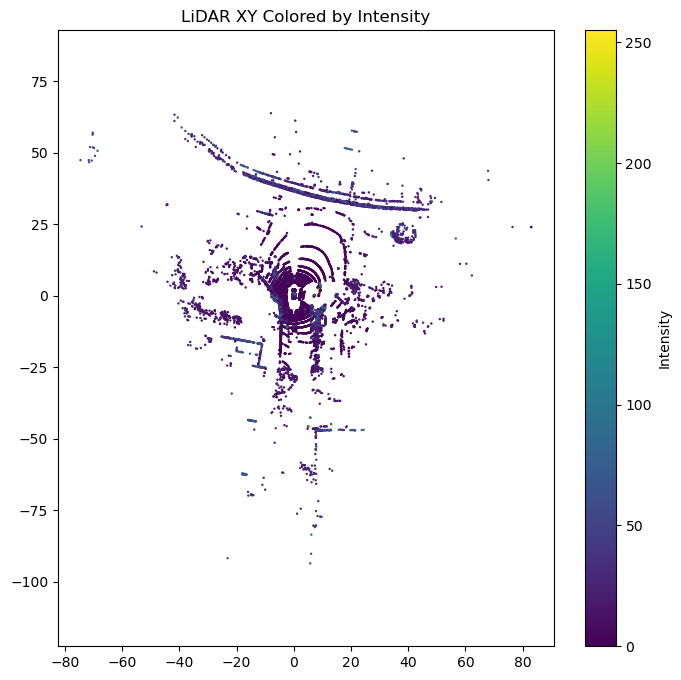

In [ ]:
intensity_sub = intensity[idx]

plt.figure(figsize=(8, 8))
plt.scatter(
    pts[:, 0],
    pts[:, 1],
    c=intensity_sub,
    s=0.5,
    cmap="viridis"
)
plt.colorbar(label="Intensity")
plt.title("LiDAR XY Colored by Intensity")
plt.axis("equal")
plt.show()

In [ ]:
clear_scenes = []

for scene in nusc.scene:
    desc = scene["description"].lower()
    if "rain" not in desc:
        clear_scenes.append(scene)

print("Clear scenes:", len(clear_scenes))
print("Example clear scene:", clear_scenes[0]["description"])

Clear scenes: 9
Example clear scene: Parked truck, construction, intersection, turn left, following a van


In [ ]:
from nuscenes.utils.data_classes import LidarPointCloud
import numpy as np

def load_lidar_from_scene(scene):
    sample_token = scene["first_sample_token"]
    sample = nusc.get("sample", sample_token)

    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    lidar_file = f"{DATA_ROOT}/{lidar_data['file_name']}"
    pc = LidarPointCloud.from_file(lidar_file)

    points = pc.points.T  # (N, 4)
    xyz = points[:, :3]
    intensity = points[:, 3]

    return xyz, intensity

In [ ]:
from nuscenes.utils.data_classes import LidarPointCloud
import numpy as np

def load_lidar_from_scene(scene):
    sample_token = scene["first_sample_token"]
    sample = nusc.get("sample", sample_token)

    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    # Fix: Changed 'file_name' to 'filename'
    lidar_file = f"{DATA_ROOT}/{lidar_data['filename']}"
    pc = LidarPointCloud.from_file(lidar_file)

    points = pc.points.T  # (N, 4)
    xyz = points[:, :3]
    intensity = points[:, 3]

    return xyz, intensity

xyz_clear, intensity_clear = load_lidar_from_scene(clear_scenes[0])
xyz_rain, intensity_rain = load_lidar_from_scene(rainy_scenes[0])

print("Clear points:", xyz_clear.shape[0])
print("Rainy points:", xyz_rain.shape[0])

Clear points: 34688
Rainy points: 34400


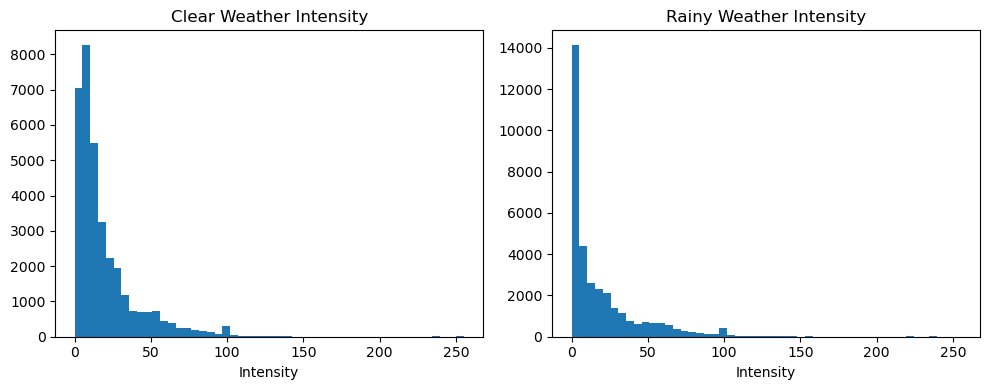

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(intensity_clear, bins=50)
plt.title("Clear Weather Intensity")
plt.xlabel("Intensity")

plt.subplot(1, 2, 2)
plt.hist(intensity_rain, bins=50)
plt.title("Rainy Weather Intensity")
plt.xlabel("Intensity")

plt.tight_layout()
plt.show()

In [ ]:
def plot_xy(xyz, title):
    idx = np.random.choice(len(xyz), size=20000, replace=False)
    pts = xyz[idx]

    plt.figure(figsize=(6, 6))
    plt.scatter(pts[:, 0], pts[:, 1], s=0.5)
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(title)
    plt.axis("equal")
    plt.show()

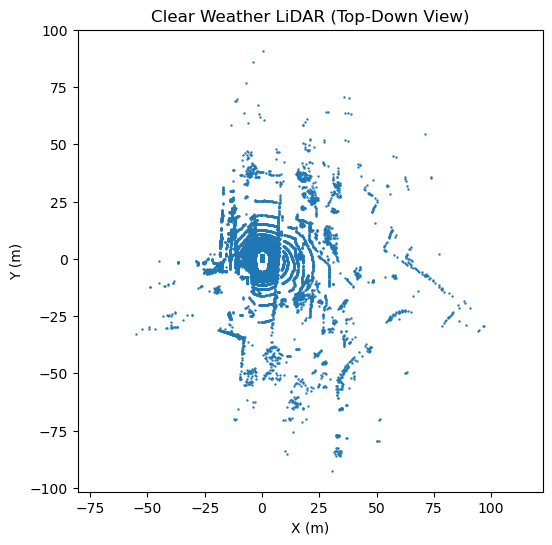

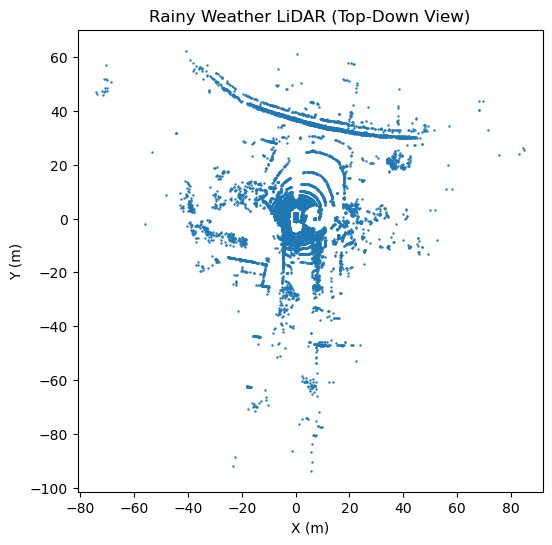

In [ ]:
plot_xy(xyz_clear, "Clear Weather LiDAR (Top-Down View)")
plot_xy(xyz_rain, "Rainy Weather LiDAR (Top-Down View)")

In [ ]:
def plot_xy_intensity(xyz, intensity, title):
    idx = np.random.choice(len(xyz), size=20000, replace=False)
    pts = xyz[idx]
    inten = intensity[idx]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        pts[:, 0], pts[:, 1],
        c=inten, s=0.5, cmap="viridis"
    )
    plt.colorbar(label="Intensity")
    plt.title(title)
    plt.axis("equal")
    plt.show()

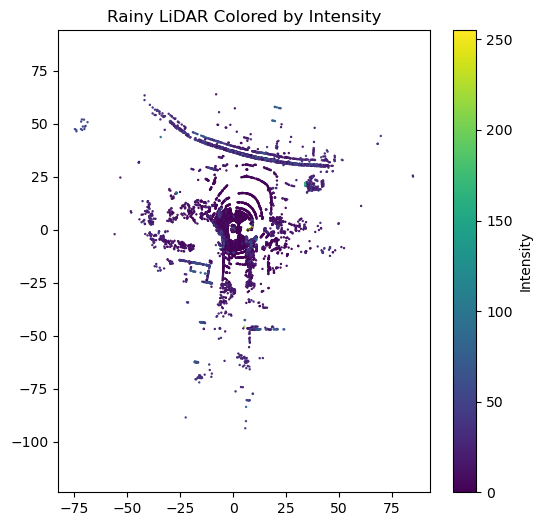

In [ ]:
plot_xy_intensity(xyz_rain, intensity_rain, "Rainy LiDAR Colored by Intensity")

In [ ]:
def point_stats(xyz, intensity, name):
    print(f"{name}")
    print("  Total points:", xyz.shape[0])
    print("  Mean intensity:", intensity.mean())
    print("  Median intensity:", np.median(intensity))
    print()

point_stats(xyz_rain, intensity_rain, "Rainy (Raw)")

Rainy (Raw)
  Total points: 34400
  Mean intensity: 20.2391
  Median intensity: 9.0



In [ ]:
INTENSITY_THRESH = np.percentile(intensity_rain, 10)

mask_int = intensity_rain > INTENSITY_THRESH

xyz_int = xyz_rain[mask_int]
int_int = intensity_rain[mask_int]

point_stats(xyz_int, int_int, "After Intensity Filter")

After Intensity Filter
  Total points: 30302
  Mean intensity: 22.874762
  Median intensity: 12.0



In [ ]:
from sklearn.neighbors import NearestNeighbors

def statistical_outlier_filter(xyz, k=20, std_ratio=1.0):
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(xyz)
    distances, _ = nbrs.kneighbors(xyz)
    mean_dist = distances[:, 1:].mean(axis=1)

    threshold = mean_dist.mean() + std_ratio * mean_dist.std()
    mask = mean_dist < threshold

    return xyz[mask], mask

In [ ]:
xyz_stat, mask_stat = statistical_outlier_filter(xyz_int, k=20, std_ratio=1.0)
int_stat = int_int[mask_stat]

point_stats(xyz_stat, int_stat, "After Statistical Outlier Filter")

After Statistical Outlier Filter
  Total points: 27906
  Mean intensity: 22.889845
  Median intensity: 11.0



In [ ]:
def radius_outlier_filter(xyz, radius=0.5, min_neighbors=5):
    nbrs = NearestNeighbors(radius=radius).fit(xyz)
    neighbors = nbrs.radius_neighbors(xyz, return_distance=False)
    mask = np.array([len(n) >= min_neighbors for n in neighbors])
    return xyz[mask], mask

In [ ]:
xyz_rad, mask_rad = radius_outlier_filter(xyz_stat, radius=0.5, min_neighbors=5)
int_rad = int_stat[mask_rad]

point_stats(xyz_rad, int_rad, "After Radius Outlier Filter")

After Radius Outlier Filter
  Total points: 25159
  Mean intensity: 22.573751
  Median intensity: 9.0



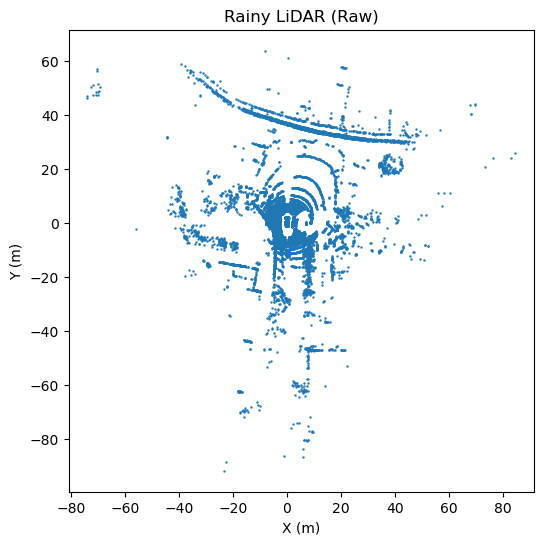

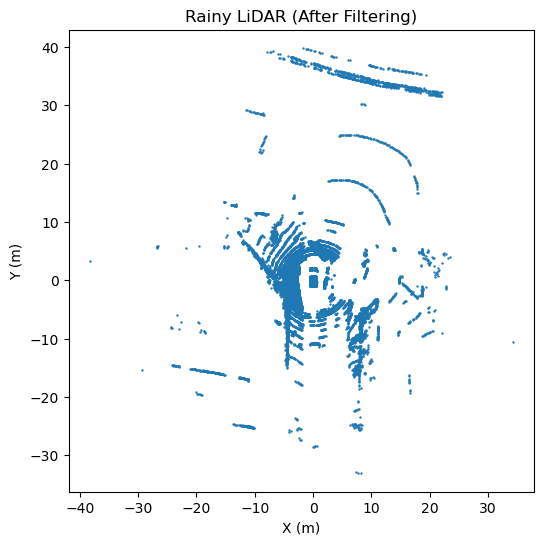

In [ ]:
plot_xy(xyz_rain, "Rainy LiDAR (Raw)")
plot_xy(xyz_rad, "Rainy LiDAR (After Filtering)")

In [ ]:
print("Points removed (%):",
      100 * (1 - xyz_rad.shape[0] / xyz_rain.shape[0]))

Points removed (%): 26.86337209302325


In [ ]:
def get_lidar_sequence(scene, n_frames=10):
    samples = []
    token = scene["first_sample_token"]

    for _ in range(n_frames):
        sample = nusc.get("sample", token)
        lidar_token = sample["data"]["LIDAR_TOP"]
        lidar_data = nusc.get("sample_data", lidar_token)

        # Fix: Changed 'file_name' to 'filename'
        pc = LidarPointCloud.from_file(f"{DATA_ROOT}/{lidar_data['filename']}")
        samples.append(pc.points.T[:, :3])

        token = sample["next"]
        if token == "":
            break

    return samples

In [ ]:
rain_seq_raw = get_lidar_sequence(rainy_scenes[0])

In [ ]:
from sklearn.cluster import DBSCAN

def cluster_points(xyz, eps=1.5, min_samples=20):
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(xyz)
    labels = clustering.labels_
    clusters = [xyz[labels == i] for i in set(labels) if i != -1]
    return clusters

In [ ]:
def get_centroids(clusters):
    return np.array([c.mean(axis=0) for c in clusters])

In [ ]:
from scipy.spatial.distance import cdist

def associate(prev, curr, max_dist=3.0):
    if len(prev) == 0 or len(curr) == 0:
        return []

    dists = cdist(prev, curr)
    matches = []

    for i in range(len(prev)):
        j = np.argmin(dists[i])
        if dists[i, j] < max_dist:
            matches.append((i, j))

    return matches

In [ ]:
def track_sequence(sequence):
    prev_centroids = []
    lifetimes = []
    drops = 0

    for xyz in sequence:
        clusters = cluster_points(xyz)
        centroids = get_centroids(clusters)

        matches = associate(prev_centroids, centroids)
        drops += max(0, len(prev_centroids) - len(matches))

        lifetimes.append(len(matches))
        prev_centroids = centroids

    return np.mean(lifetimes), drops

In [ ]:
raw_life, raw_drops = track_sequence(rain_seq_raw)

In [ ]:
rain_seq_filt = [
    radius_outlier_filter(
        statistical_outlier_filter(
            xyz_rain, k=20, std_ratio=1.0
        )[0],
        radius=0.5,
        min_neighbors=5
    )[0]
    for xyz_rain in rain_seq_raw
]

filt_life, filt_drops = track_sequence(rain_seq_filt)

In [ ]:
def plot_tracks(sequence, title):
    tracks = []

    prev = None
    for xyz in sequence:
        clusters = cluster_points(xyz)
        centroids = get_centroids(clusters)
        tracks.append(centroids)

    plt.figure(figsize=(6, 6))
    for frame in tracks:
        plt.scatter(frame[:, 0], frame[:, 1], s=10)
    plt.title(title)
    plt.axis("equal")
    plt.show()

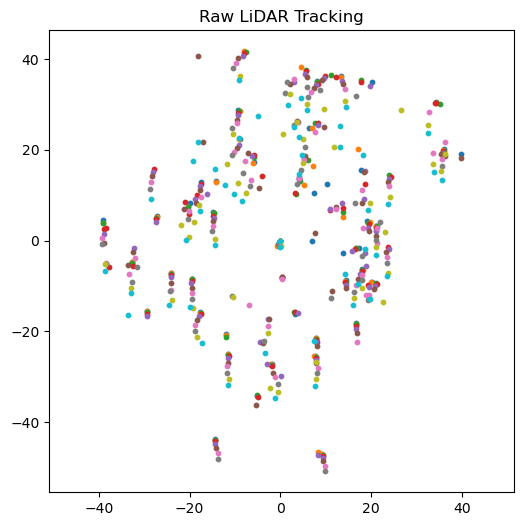

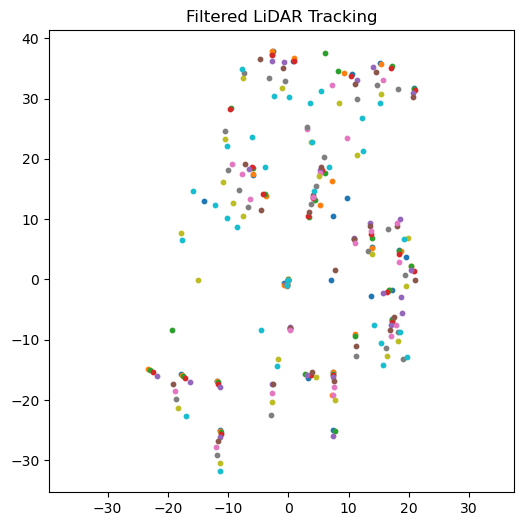

In [ ]:
plot_tracks(rain_seq_raw, "Raw LiDAR Tracking")
plot_tracks(rain_seq_filt, "Filtered LiDAR Tracking")

In [ ]:
def detect_objects(xyz, intensity, eps=1.5, min_samples=20):
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(xyz)
    labels = clustering.labels_

    detections = []
    for lab in set(labels):
        if lab == -1:
            continue
        pts = xyz[labels == lab]
        inten = intensity[labels == lab]

        confidence = len(pts) * inten.mean()
        centroid = pts.mean(axis=0)

        detections.append({
            "confidence": confidence,
            "centroid": centroid,
            "num_points": len(pts)
        })
    return detections

In [ ]:
raw_dets = detect_objects(xyz_rain, intensity_rain)
filt_dets = detect_objects(xyz_rad, int_rad)

print("Raw detections:", len(raw_dets))
print("Filtered detections:", len(filt_dets))

Raw detections: 42
Filtered detections: 22


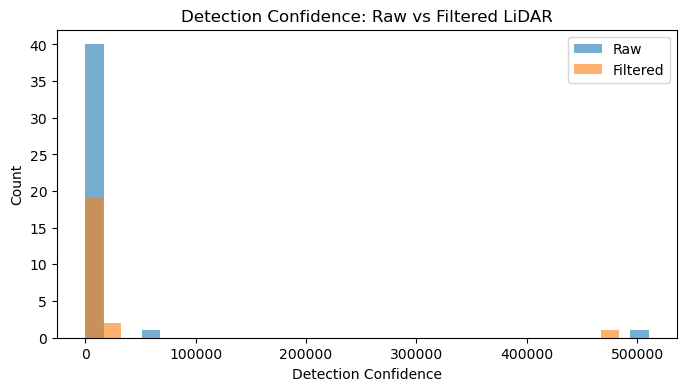

In [ ]:
raw_conf = [d["confidence"] for d in raw_dets]
filt_conf = [d["confidence"] for d in filt_dets]

plt.figure(figsize=(8, 4))
plt.hist(raw_conf, bins=30, alpha=0.6, label="Raw")
plt.hist(filt_conf, bins=30, alpha=0.6, label="Filtered")
plt.xlabel("Detection Confidence")
plt.ylabel("Count")
plt.legend()
plt.title("Detection Confidence: Raw vs Filtered LiDAR")
plt.show()

In [ ]:
CONF_THRESH = np.percentile(raw_conf, 25)

raw_weak = sum(c < CONF_THRESH for c in raw_conf)
filt_weak = sum(c < CONF_THRESH for c in filt_conf)

print("Weak detections (raw):", raw_weak)
print("Weak detections (filtered):", filt_weak)

Weak detections (raw): 11
Weak detections (filtered): 6


In [ ]:
def plot_detections(dets, title):
    pts = np.array([d["centroid"] for d in dets])
    conf = np.array([d["confidence"] for d in dets])

    plt.figure(figsize=(6, 6))
    plt.scatter(pts[:, 0], pts[:, 1], c=conf, cmap="plasma", s=30)
    plt.colorbar(label="Detection Confidence")
    plt.title(title)
    plt.axis("equal")
    plt.show()

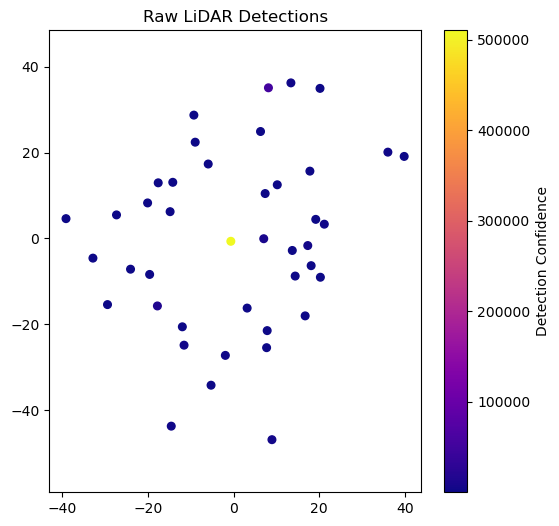

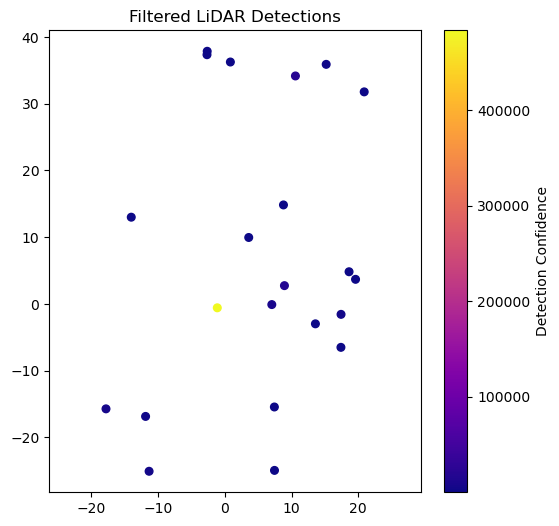

In [ ]:
plot_detections(raw_dets, "Raw LiDAR Detections")
plot_detections(filt_dets, "Filtered LiDAR Detections")

In [ ]:
import open3d as o3d
import numpy as np

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz_rain)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
z = xyz_rain[:, 2]
z_norm = (z - z.min()) / (z.max() - z.min())

colors = plt.cm.viridis(z_norm)[:, :3]
pcd.colors = o3d.utility.Vector3dVector(colors)

In [ ]:
o3d.visualization.draw_geometries(
    [pcd],
    window_name="LiDAR Colored by Height",
    width=1200,
    height=800
)

In [ ]:
inten_norm = (intensity_rain - intensity_rain.min()) / (
    intensity_rain.max() - intensity_rain.min()
)

colors = plt.cm.plasma(inten_norm)[:, :3]
pcd.colors = o3d.utility.Vector3dVector(colors)

o3d.visualization.draw_geometries([pcd])